# Swahili Sentiment Analysis — Data Preprocessing

This notebook walks through the preprocessing pipeline step by step.

> **Tip:** Run `src/preprocess.py` for the production pipeline. This notebook is for exploration and visualisation.

In [8]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn emoji

In [9]:
import re, os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')   # allow imports from src/

%matplotlib inline
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

In [10]:
df = pd.read_csv('../data/raw/dev.tsv', sep='\t')
print(f'Shape: {df.shape}')
df.head()

Shape: (453, 2)


,tweet,label
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative


In [11]:
print(df.info())
print('\nLabel distribution:')
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   453 non-null    object
 1   label   453 non-null    object
dtypes: object(2)
memory usage: 7.2+ KB
None

Label distribution:
label
neutral     268
positive    137
negative     48
Name: count, dtype: int64


## 2. Visualise Label Distribution

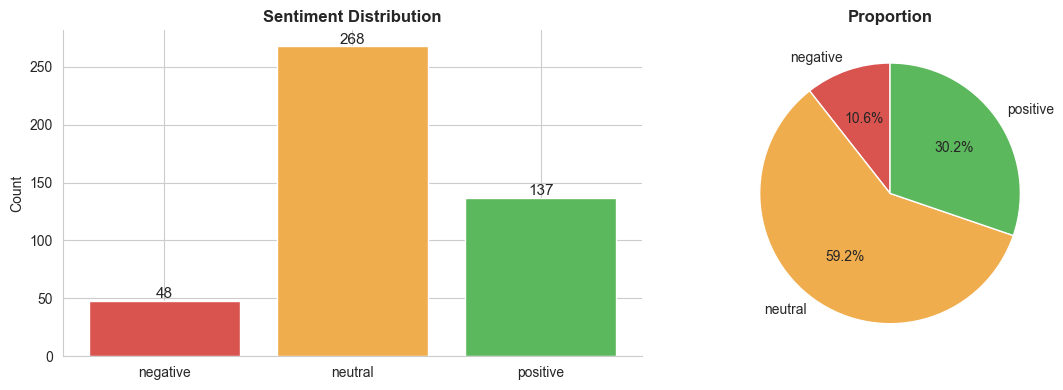

Chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
order = ['negative', 'neutral', 'positive']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
counts = df['label'].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=colors, edgecolor='white')
for i, (label, val) in enumerate(zip(order, counts.values)):
    axes[0].text(i, val + 2, str(val), ha='center', fontsize=11)
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=order, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion', fontweight='bold')

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 3. Text Cleaning

In [13]:
try:
    import emoji
    EMOJI = True
except ImportError:
    EMOJI = False

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    if EMOJI:
        text = emoji.replace_emoji(text, replace='')
    else:
        text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF]+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = 'Habari! 😊 Check https://example.com @user #Kenya leo'
print('Original: ', sample)
print('Cleaned:  ', clean_text(sample))

Original:  Habari! 😊 Check https://example.com @user #Kenya leo
Cleaned:   habari check kenya leo


In [14]:
df['clean_text'] = df['tweet'].apply(clean_text)
df[['tweet', 'clean_text']].head(8)

,tweet,clean_text
0,Leo nimepata kitambulisho changu cha taifa Asa...,leo nimepata kitambulisho changu cha taifa asa...
1,Asante na tafadhali subiri tutawasiliana nawe ...,asante na tafadhali subiri tutawasiliana nawe ...
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,takwimu zinaonyesha katika kila watoto wanapat...
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,sio watu wazuri awa nakutana nao fa cup nawafa...
5,Tanzania Hii Ukiwa Boyfriend Unakuwa Na Majuku...,tanzania hii ukiwa boyfriend unakuwa na majuku...
6,Kampuni ya imedhamiria kupanua shughuli zao zi...,kampuni ya imedhamiria kupanua shughuli zao zi...
7,WordSema lowkey hii siku hizi ni kama Mbio za ...,wordsema lowkey hii siku hizi ni kama mbio za ...


## 4. Text Length Analysis

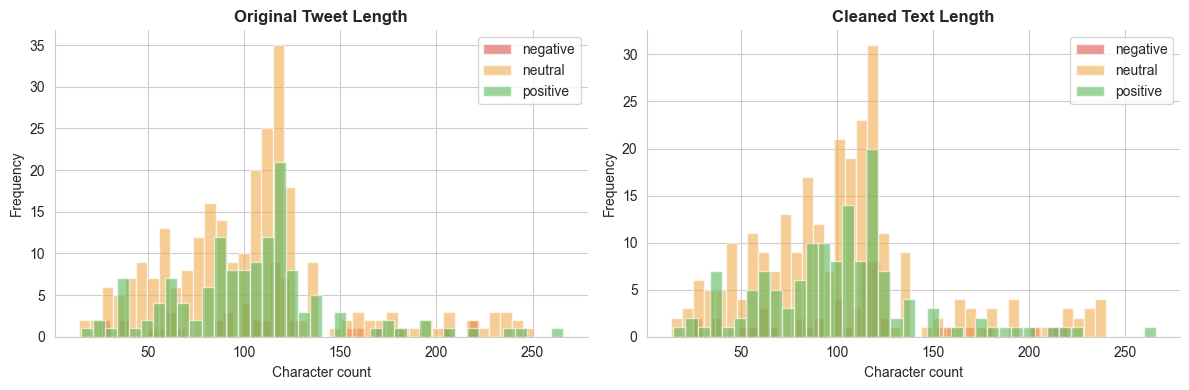

In [15]:
df['original_len'] = df['tweet'].str.len()
df['cleaned_len']  = df['clean_text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['original_len', 'cleaned_len'],
                           ['Original Tweet Length', 'Cleaned Text Length']):
    for label, color in zip(['negative','neutral','positive'], ['#d9534f','#f0ad4e','#5cb85c']):
        subset = df[df['label'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, label=label, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Character count')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Label Encoding

In [16]:
LABEL_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label_encoded'] = df['label'].map(LABEL_MAP)
print(df[['label', 'label_encoded']].value_counts().sort_index())
df.head()

label     label_encoded
negative  0                 48
neutral   1                268
positive  2                137
Name: count, dtype: int64


,tweet,label,clean_text,original_len,cleaned_len,label_encoded
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive,leo nimepata kitambulisho changu cha taifa asa...,54,54,2
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive,asante na tafadhali subiri tutawasiliana nawe ...,67,67,2
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral,takwimu zinaonyesha katika kila watoto wanapat...,85,75,1
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral,kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,228,228,1
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative,sio watu wazuri awa nakutana nao fa cup nawafa...,54,54,0


## 6. Save Processed Data

In [17]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_data.csv', index=False)
print(f'Saved {len(df):,} rows to data/processed/cleaned_data.csv')
df[['tweet', 'clean_text', 'label', 'label_encoded']].sample(5, random_state=42)

Saved 453 rows to data/processed/cleaned_data.csv


,tweet,clean_text,label,label_encoded
352,ndo mana mchungaji msigwa anamuambiaaga anaogo...,ndo mana mchungaji msigwa anamuambiaaga anaogo...,neutral,1
39,John Mrema Tumekuwa na mafunzo kwa wanawakekil...,john mrema tumekuwa na mafunzo kwa wanawakekil...,positive,2
361,Habari Tafadhali piga 14700 au 14800 chagua sa...,habari tafadhali piga au chagua saizi yako sik...,positive,2
358,Habari Ahsante kwa kuwasiliana nasi Naomba nik...,habari ahsante kwa kuwasiliana nasi naomba nik...,positive,2
154,Aisee bro life ni gumu sanaa kitaaa unaweza fi...,aisee bro life ni gumu sanaa kitaaa unaweza fi...,negative,0
